In [26]:
import modified_didppy as m_dp
import pandas as pd
import math
import matplotlib.pyplot as plt
import random
from functools import reduce
import time as pytime
import builtins   # ✅ ensures we use real built-in functions
import re
import os
import glob
import sys


# **Data**

In [4]:
def load_jsp_file(file_path):
    """
    Reads the content of a JSP instance file from disk.
    
    Args:
        file_path (str): The absolute or relative path to the .txt file.
        
    Returns:
        str: The raw string content of the file.
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file was not found at: {file_path}")
    
    with open(file_path, 'r') as f:
        content = f.read()
    
    return content

In [5]:
def parse_jsp_instance(file_content):
    """
    Parses a JSP instance string (Taillard/Beasley format) and generates 
    ALL sets/parameters required for both LP Relaxation and DIDP models.
    
    Args:
        file_content (str): The raw text content of the instance file.
        
    Returns:
        dict: A dictionary containing all sets (J, M, N, A, B, etc.) and parameters.
    """
    # ---------------------------------------------------------
    # 1. Basic Parsing (Clean comments and header)
    # ---------------------------------------------------------
    lines = file_content.strip().split('\n')
    data_tokens = []
    
    for line in lines:
        # Remove comments (lines starting with # or [)
        if not line.strip() or line.strip().startswith('#') or line.strip().startswith('['):
            continue
        # Extract numbers
        tokens = re.findall(r'\d+', line)
        data_tokens.extend([int(t) for t in tokens])
        
    iterator = iter(data_tokens)
    
    try:
        num_jobs = next(iterator)
        num_machines = next(iterator)
    except StopIteration:
        raise ValueError("File is empty or invalid format")

    # ---------------------------------------------------------
    # 2. Raw Job Data Extraction
    # ---------------------------------------------------------
    # jobs_data format: [ [(machine, time), (machine, time)], ... ]
    jobs_data = []
    for _ in range(num_jobs):
        job_seq = []
        for _ in range(num_machines):
            m = next(iterator)
            p = next(iterator)
            job_seq.append((m, p))
        jobs_data.append(job_seq)

    num_operations = num_jobs * num_machines

    # ---------------------------------------------------------
    # 3. Build Structures for LP Relaxation (Lecture Note Style)
    # ---------------------------------------------------------
    # Sets based on (machine, job) tuples
    N = []              # Nodes: List of (m, j)
    A = []              # Solid Arcs: List of ((m_prev, j), (m_curr, j))
    B = []              # Broken Arcs (Graph): List of ((m, j), (m, k))
    B_flat = []         # Broken Arcs (LP Triplet): List of (m, j, k)
    p_mj = {}           # Processing time map: {(m, j): time}
    
    # Helpers for Broken Arcs
    machine_allocations = {m: [] for m in range(num_machines)}

    for j_idx, job_seq in enumerate(jobs_data):
        prev_node = None
        for (m, p) in job_seq:
            curr_node = (m, j_idx)
            
            # Populate N and p_mj
            N.append(curr_node)
            p_mj[curr_node] = float(p)
            
            # Populate Solid Arcs (A)
            if prev_node is not None:
                A.append((prev_node, curr_node))
            
            # Track for Broken Arcs
            machine_allocations[m].append(j_idx)
            prev_node = curr_node

    # Populate Broken Arcs - pairs on same machine
    for m in range(num_machines):
        assigned_jobs = machine_allocations[m]
        for i in range(len(assigned_jobs)):
            for k in range(i + 1, len(assigned_jobs)):
                job_1 = assigned_jobs[i]
                job_2 = assigned_jobs[k]
                
                # 1. Standard Disjunctive Graph Arc: ((m, j), (m, k))
                # Useful for graph plotting and disjunctive graph algos
                B.append(((m, job_1), (m, job_2)))
                
                # 2. Flat Triplet for LP variables: (m, j, k)
                # Useful for PuLP variables x_mjk
                B_flat.append((m, job_1, job_2))

    # ---------------------------------------------------------
    # 4. Build Structures for DIDP (Operation Index Style)
    # ---------------------------------------------------------
    # Flattened Operation ID: 0 to num_operations-1
    op_job_type = []
    op_required_machine_type = []
    op_processing_time = []
    op_predecessors = []
    op_deadline = []
    op_same_job = [[] for _ in range(num_operations)] # SJ_jo
    ops_on_machine = [[] for _ in range(num_machines)] # AO_k
    
    # Mapping to convert between (m,j) and op_id
    map_mj_to_op = {}
    
    # Define a default deadline (e.g., a large number covering the horizon)
    DEFAULT_DEADLINE = float('inf')
    
    op_counter = 0
    for j_idx, job_seq in enumerate(jobs_data):
        job_ops_indices = []
        
        for i, (m, p) in enumerate(job_seq):
            # Basic Attributes
            op_job_type.append(j_idx)
            op_required_machine_type.append(m)
            op_processing_time.append(float(p))
            op_deadline.append(DEFAULT_DEADLINE)
            
            # Map tracking
            map_mj_to_op[(m, j_idx)] = op_counter
            ops_on_machine[m].append(op_counter)
            job_ops_indices.append(op_counter)
            
            # Predecessors (P_jo)
            if i > 0:
                op_predecessors.append([op_counter - 1])
            else:
                op_predecessors.append([]) # First op has no pred
            
            op_counter += 1
            
            
        # Same Job Set (SJ_jo)
        for o_id in job_ops_indices:
            # All ops in this job EXCEPT self
            op_same_job[o_id] = [x for x in job_ops_indices if x != o_id]

    # Valid Machines (VM_jo) - Simple for static JSP
    valid_machines = [[op_required_machine_type[o]] for o in range(num_operations)]

    # ---------------------------------------------------------
    # 5. Return Master Dictionary
    # ---------------------------------------------------------
    return {
        "metadata": {
            "num_jobs": num_jobs,
            "num_machines": num_machines,
            "num_operations": num_operations
        },
        
        # --- Mathematical Programming Sets (LP Relax) ---
        "LP_sets": {
            "N": N,         # Nodes (m, j)
            "A": A,         # Solid Arcs
            "B": B,         # Broken Arcs (Nested Tuples)
            "B_flat": B_flat, # Broken Arcs (Flat Triplets: m, j, k)
            "p_mj": p_mj,   # Parameter p
            "J": list(range(num_jobs)),
            "M": list(range(num_machines))
        },
        
        # --- DIDP State Sets ---
        "DIDP_sets": {
            "op_job_type": op_job_type,                 # Job J per op
            "op_required_machine_type": op_required_machine_type, # Machine M per op
            "op_processing_time": op_processing_time,   # Time p per op
            "op_predecessors": op_predecessors,        # P_jo
            "op_deadline": op_deadline,               # Deadline D_jo
            "op_same_job": op_same_job,                 # SJ_jo
            "ops_on_machine": ops_on_machine,           # AO_k
            "valid_machines": valid_machines,           # VM_jo
            "map_mj_to_op": map_mj_to_op                # Helper: (m,j) -> op_id
        }
    }

In [11]:
# =========================================================
# 3. EXECUTION & VARIABLE EXTRACTION
# =========================================================
data_file_path = r"C:\Users\ACER\Desktop\Code\0.Thesis implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\5_JSP_dual_bounds_and_models\Datasets\ft06.txt"
try:
    # 1. Load and Parse
    content = load_jsp_file(data_file_path)
    current_data = parse_jsp_instance(content)
    print("Successfully parsed instance!")
    print(f"Jobs: {current_data['metadata']['num_jobs']}, Machines: {current_data['metadata']['num_machines']}")

    
    # 2. Extract basic data
    current_number_of_operations = current_data['metadata']['num_operations']
    current_number_of_machines = current_data['metadata']['num_machines']
    current_number_of_jobs = current_data['metadata']['num_jobs']
    
    # 3. Extract LP Relaxation Variables
    lp_data = current_data['LP_sets']
    current_N = lp_data['N']          # Nodes
    current_A = lp_data['A']          # Solid Arcs
    current_B = lp_data['B']          # Broken Arcs (Nested Tuples)
    current_B_flat = lp_data['B_flat']# Broken Arcs (Flat Tuples)
    current_p_mj = lp_data['p_mj']    # Processing Times
    current_J = lp_data['J']          # Set of Jobs
    current_M = lp_data['M']          # Set of Machines

    # 3. Extract DIDP Variables
    didp_data = current_data['DIDP_sets']
    current_op_job_type = didp_data['op_job_type']
    current_op_required_machine_type = didp_data['op_required_machine_type']
    current_op_processing_time = didp_data['op_processing_time']
    current_op_deadline = didp_data['op_deadline']
    current_op_predecessors = didp_data['op_predecessors']
    current_op_same_job = didp_data['op_same_job']
    current_ops_on_machine = didp_data['ops_on_machine']
    current_valid_machines = didp_data['valid_machines']
    current_map_mj_to_op = didp_data['map_mj_to_op']

    # 4. Verify Extraction
    print("\n--- LP Variables Extracted ---")
    print(f"N: {len(current_N)} nodes")
    print(f"B_flat: {len(current_B_flat)} disjunctive triplets")
    
    print("\n--- DIDP Variables Extracted ---")
    print(f"op_processing_time: {len(current_op_processing_time)} entries")
    print(f"ops_on_machine[0]: {len(current_ops_on_machine[0])} operations on Machine 0")
    print(f"Processingtime of operations:{current_op_processing_time}")

except FileNotFoundError:
    print(f"Error: The file was not found at {data_file_path}")
except Exception as e:
    print(f"An error occurred: {e}")


Successfully parsed instance!
Jobs: 6, Machines: 6

--- LP Variables Extracted ---
N: 36 nodes
B_flat: 90 disjunctive triplets

--- DIDP Variables Extracted ---
op_processing_time: 36 entries
ops_on_machine[0]: 6 operations on Machine 0
Processingtime of operations:[1.0, 3.0, 6.0, 7.0, 3.0, 6.0, 8.0, 5.0, 10.0, 10.0, 10.0, 4.0, 5.0, 4.0, 8.0, 9.0, 1.0, 7.0, 5.0, 5.0, 5.0, 3.0, 8.0, 9.0, 9.0, 3.0, 5.0, 4.0, 3.0, 1.0, 3.0, 3.0, 9.0, 10.0, 4.0, 1.0]


# **DIDP model**

In [ ]:
def creation_of_didp_model_function():
    # -----------------------------
    # 1. Retrieve Global Variables
    # -----------------------------
    num_operations = current_number_of_operations
    num_machines = current_number_of_machines
    op_processing_time = current_op_processing_time
    op_deadline = current_op_deadline
    op_predecessors = current_op_predecessors
    op_same_job = current_op_same_job
    valid_machines = current_valid_machines
    ops_on_machine = current_ops_on_machine
    
    # NEW: Added requested variables
    op_job_type = current_op_job_type
    op_required_machine_type = current_op_required_machine_type

    # -----------------------------
    # 2. DIDP Model and Constants
    # -----------------------------
    model = m_dp.Model(maximize=False, float_cost=True)

    operation_obj = model.add_object_type(number=num_operations)
    machine_obj = model.add_object_type(number=num_machines)

    # Constant tables
    processing_time_table = model.add_float_table(op_processing_time)
    deadline_table = model.add_float_table(op_deadline)
    predecessor_table = model.add_set_table(op_predecessors, object_type=operation_obj)
    same_job_table = model.add_set_table(op_same_job, object_type=operation_obj)
    valid_machine_table = model.add_set_table(valid_machines, object_type=operation_obj)

    # -----------------------------
    # 3. State Variables
    # -----------------------------
    unscheduled_operations = model.add_set_var(object_type=operation_obj,
                                    target=list(range(num_operations)))
    finished_operations = model.add_set_var(object_type=operation_obj, target=[])
    machine_available_time = [
        model.add_float_resource_var(target=0, less_is_better=True, name=f"at_{mi}")
        for mi in range(num_machines)
    ]
    op_completion_time = [
        model.add_float_resource_var(target=0, less_is_better=True, name=f"c_{jo}")
        for jo in range(num_operations)
    ]

    # ------------------------------------------------------------
    # 4. Transitions
    # ------------------------------------------------------------
    # Schedule operation jo on the specified machine
    # ------------------------------------------------------------
    for o in range(num_operations):
        valid_machines_for_op = valid_machines[o]
        expr = m_dp.FloatExpr(0)
        #Finding the completion time of the predecessors to make sure 1 job cannot be operated on 2 machines at the same time
        if op_same_job[o]:
            job_exprs = [op_completion_time[k] for k in op_same_job[o]]
            expr = job_exprs[0]
            for e in job_exprs[1:]:
                expr = m_dp.max(expr, e)
        max_same_job_completion_time = expr
        for m in valid_machines_for_op:
            # Compute start & completion
            start_time = m_dp.max(machine_available_time[m], max_same_job_completion_time)
            completion_time = start_time + processing_time_table[o]
            cost_expr = m_dp.FloatExpr.state_cost()
            transition = m_dp.Transition(
                name=f"schedule_op{o}_on_m{m}",
                cost=cost_expr,
                preconditions=[
                    unscheduled_operations.contains(o),
                    predecessor_table[o].issubset(finished_operations),
                    completion_time <= deadline_table[o],
                ],
                effects=[
                    (unscheduled_operations, unscheduled_operations.remove(o)),
                    (finished_operations, finished_operations.add(o)),
                    (op_completion_time[o], completion_time),
                    (machine_available_time[m], completion_time),
                ],
            )
            model.add_transition(transition)

    # ------------------------------------------------------------
    # 5. Base case
    # ------------------------------------------------------------
    makespan = m_dp.FloatExpr(0)
    for o in range(num_operations):
        makespan = m_dp.max(makespan, op_completion_time[o])
    model.add_base_case([unscheduled_operations.is_empty()], cost=makespan)

    # ------------------------------------------------------------
    # 6. State Constraints
    # ------------------------------------------------------------
    # Enforce 0 <= completion time <= deadline for all operations
    for o in range(num_operations):
        # Upper bound: c(o) <= d(o)
        model.add_state_constr(op_completion_time[o] <= deadline_table[o])

    # ------------------------------------------------------------
    # 7. Dual Bound (optional)
    # ------------------------------------------------------------
    # Machine-based bound: for each machine m, available_time[m] + sum(remaining ptime on that machine)
    ops_on_machine_consts = [
        model.create_set_const(object_type=operation_obj, value=ops) for ops in ops_on_machine
    ]
    # remaining processing time on machine m = sum of ptime for operations on m that are still unscheduled
    remaining_time_on_machine = [
        processing_time_table[unscheduled_operations.intersection(ops_on_machine_consts[m])]
        for m in range(num_machines)
    ]
    machine_bound_exprs = [
        machine_available_time[m] + remaining_time_on_machine[m]
        for m in range(num_machines)
    ]

    # fold to a single dp.max expression
    dual_bound_expr = machine_bound_exprs[0]
    for b in machine_bound_exprs[1:]:
        dual_bound_expr = m_dp.max(dual_bound_expr, b)

    # Add dual bound to model
    model.add_dual_bound(dual_bound_expr)

    # =========================================================
    # 8. Bundle Metadata
    # =========================================================
    metadata = {
        "unscheduled_operations": unscheduled_operations,
        "finished_operations": finished_operations,
        "machine_available_time": machine_available_time,
        "op_completion_time": op_completion_time,
        # Added the requested new variables to metadata
        "op_job_type": op_job_type,
        "op_required_machine_type": op_required_machine_type
    }
    
    didp_bundle = (model, metadata)
    return didp_bundle




# **Execution**

In [28]:
# ==========================================
# 1. Configuration & File Selection
# ==========================================

# Directory containing the JSP instances (Update this path if needed)
folder_path = r"C:\Users\ACER\Desktop\Code\0.Thesis implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\5_JSP_dual_bounds_and_models\Datasets" 

# Get all .txt files
all_files = glob.glob(os.path.join(folder_path, "*.txt"))

# Select 20 random instances (or all if less than 20)
num_instances_to_test = 1
if len(all_files) > num_instances_to_test:
    selected_files = random.sample(all_files, num_instances_to_test)
else:
    selected_files = all_files

print(f"Found {len(all_files)} files. Selected {len(selected_files)} for testing.")
print("Selected Instances:")
for f in selected_files:
    print(f" - {os.path.basename(f)}")
print("-" * 50)

# ==========================================
# 2. Testing Loop
# ==========================================

results_data = []
output_csv_name = "JSP_single_dual_bound_results.csv"

# Ensure global variables exist (initializing them)
current_number_of_operations = 0
current_number_of_machines = 0
current_number_of_jobs = 0
current_op_job_type = []
current_op_required_machine_type = []
current_op_processing_time = []
current_op_deadline = []
current_op_predecessors = []
current_op_same_job = []
current_ops_on_machine = []
current_valid_machines = []
current_map_mj_to_op = {}

for i, file_path in enumerate(selected_files):
    instance_name = os.path.basename(file_path)
    print(f"\n[{i+1}/{len(selected_files)}] Processing: {instance_name}")
    
    try:
        # --- A. Read Data & Update Globals ---
        # 1. Read file content
        with open(file_path, 'r') as f:
            content = f.read()
            
        # 2. Parse using your custom function
        current_data = parse_jsp_instance(content)
        
        # 3. EXTRACT AND UPDATE GLOBALS 
        # (Crucial: The model function relies on these exact global variable names)
        didp_data = current_data['DIDP_sets']
        
        current_number_of_operations = current_data['metadata']['num_operations']
        current_number_of_machines = current_data['metadata']['num_machines']
        current_number_of_jobs = current_data['metadata']['num_jobs']
        
        current_op_job_type = didp_data['op_job_type']
        current_op_required_machine_type = didp_data['op_required_machine_type']
        current_op_processing_time = didp_data['op_processing_time']
        current_op_deadline = didp_data['op_deadline']
        current_op_predecessors = didp_data['op_predecessors']
        current_op_same_job = didp_data['op_same_job']
        current_ops_on_machine = didp_data['ops_on_machine']
        current_valid_machines = didp_data['valid_machines']
        current_map_mj_to_op = didp_data['map_mj_to_op']

        # --- B. Initialize Model ---
        # Call your existing function (which reads the globals we just set)
        didp_bundle = creation_of_didp_model_function()
        model, metadata = didp_bundle # Unpack the tuple
        
        # --- C. Solver Execution ---
        t_start = pytime.time()
        
        # Solver with 1 hour limit (3600 seconds)
        solver = m_dp.CABS(
            model,
            quiet=True, # Set to True to reduce console spam
            time_limit=10
        )
        
        solution = solver.search()
        
        t_end = pytime.time()
        duration = t_end - t_start
        
        # --- D. Logging Results ---
        if solution.is_optimal:
             cost = solution.cost
             status = "True"
        elif solution.cost is not None:
             cost = solution.cost
             status = "False (Time Limit)"
        else:
             cost = "Inf"
             status = "False (No Sol)"

        nodes_gen = solution.generated
        nodes_exp = solution.expanded
        
        print(f"   -> Done. Cost: {cost}, Time: {duration:.2f}s, Optimal: {status}")

        # Append to results list
        results_data.append({
            "Instance": instance_name,
            "Cost": cost,
            "Nodes Expanded": nodes_exp,
            "Nodes Generated": nodes_gen,
            "Running Time (s)": duration,
            "Is Optimal": status
        })

    except Exception as e:
        print(f"   -> ERROR processing {instance_name}: {e}")
        # Optional: print full traceback if debugging
        # import traceback
        # traceback.print_exc()
        
        results_data.append({
            "Instance": instance_name,
            "Cost": "Error",
            "Nodes Expanded": 0,
            "Nodes Generated": 0,
            "Running Time (s)": 0,
            "Is Optimal": "Error"
        })

    # --- E. Intermediate Save ---
    # Save after every iteration for safety
    df_results = pd.DataFrame(results_data)
    df_results.to_csv(output_csv_name, index=False)

print("\n" + "="*50)
print("Batch Testing Complete.")
print(f"Results saved to {output_csv_name}")
print(df_results)

Found 3 files. Selected 1 for testing.
Selected Instances:
 - ft06.txt
--------------------------------------------------

[1/1] Processing: ft06.txt
   -> Done. Cost: 55.0, Time: 10.04s, Optimal: False (Time Limit)

Batch Testing Complete.
Results saved to JSP_single_dual_bound_results.csv
   Instance  Cost  Nodes Expanded  Nodes Generated  Running Time (s)  \
0  ft06.txt  55.0           56172            76378         10.040109   

           Is Optimal  
0  False (Time Limit)  


# **Visualization**

Successfully parsed instance!
Jobs: 6, Machines: 6

--- LP Variables Extracted ---
N: 36 nodes
B_flat: 90 disjunctive triplets

--- DIDP Variables Extracted ---
op_processing_time: 36 entries
ops_on_machine[0]: 6 operations on Machine 0
Processingtime of operations:[1.0, 3.0, 6.0, 7.0, 3.0, 6.0, 8.0, 5.0, 10.0, 10.0, 10.0, 4.0, 5.0, 4.0, 8.0, 9.0, 1.0, 7.0, 5.0, 5.0, 5.0, 3.0, 8.0, 9.0, 9.0, 3.0, 5.0, 4.0, 3.0, 1.0, 3.0, 3.0, 9.0, 10.0, 4.0, 1.0]
Solution cost: 55.0

--- Solution Transitions ---
schedule_op0_on_m2
schedule_op12_on_m2
schedule_op6_on_m1
schedule_op30_on_m1
schedule_op13_on_m3
schedule_op7_on_m2
schedule_op24_on_m2
schedule_op18_on_m1
schedule_op25_on_m1
schedule_op31_on_m3
schedule_op1_on_m0
schedule_op2_on_m1
schedule_op19_on_m0
schedule_op14_on_m5
schedule_op32_on_m5
schedule_op8_on_m4
schedule_op15_on_m0
schedule_op9_on_m5
schedule_op26_on_m4
schedule_op33_on_m0
schedule_op10_on_m0
schedule_op20_on_m2
schedule_op16_on_m1
schedule_op21_on_m3
schedule_op22_on_m4
schedu

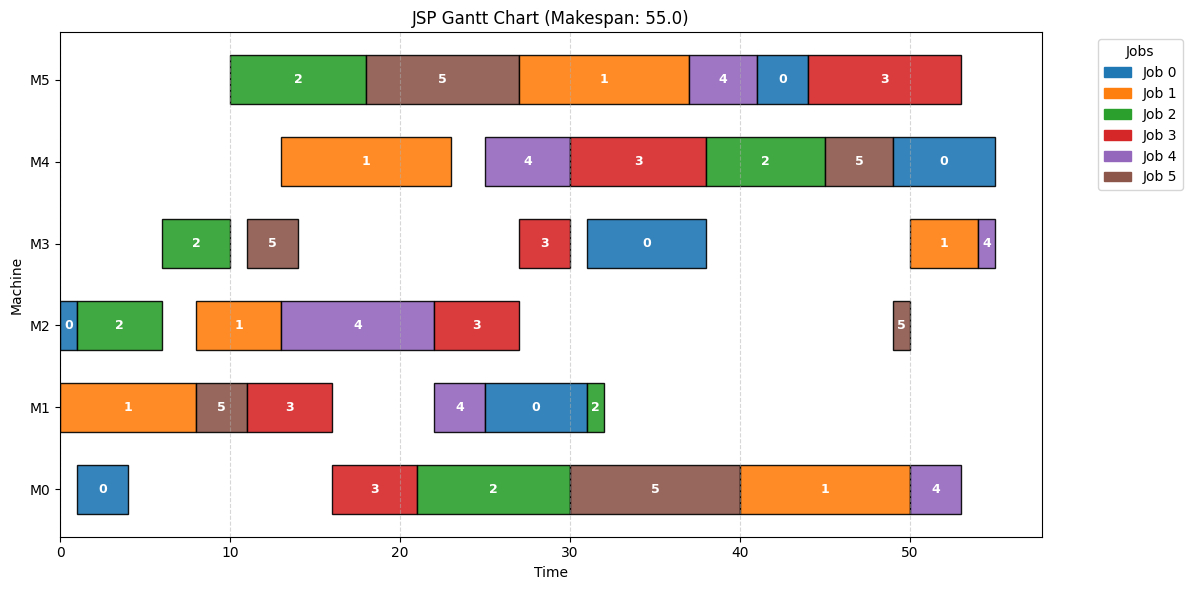

In [29]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import re
import numpy as np

# =========================================================
# 3. EXECUTION & VARIABLE EXTRACTION
# =========================================================
data_file_path = r"C:\Users\ACER\Desktop\Code\0.Thesis implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\5_JSP_dual_bounds_and_models\Datasets\ft06.txt"
try:
    # 1. Load and Parse
    content = load_jsp_file(data_file_path)
    current_data = parse_jsp_instance(content)
    print("Successfully parsed instance!")
    print(f"Jobs: {current_data['metadata']['num_jobs']}, Machines: {current_data['metadata']['num_machines']}")

    
    # 2. Extract basic data
    current_number_of_operations = current_data['metadata']['num_operations']
    current_number_of_machines = current_data['metadata']['num_machines']
    current_number_of_jobs = current_data['metadata']['num_jobs']
    
    # 3. Extract LP Relaxation Variables
    lp_data = current_data['LP_sets']
    current_N = lp_data['N']          # Nodes
    current_A = lp_data['A']          # Solid Arcs
    current_B = lp_data['B']          # Broken Arcs (Nested Tuples)
    current_B_flat = lp_data['B_flat']# Broken Arcs (Flat Tuples)
    current_p_mj = lp_data['p_mj']    # Processing Times
    current_J = lp_data['J']          # Set of Jobs
    current_M = lp_data['M']          # Set of Machines

    # 3. Extract DIDP Variables
    didp_data = current_data['DIDP_sets']
    current_op_job_type = didp_data['op_job_type']
    current_op_required_machine_type = didp_data['op_required_machine_type']
    current_op_processing_time = didp_data['op_processing_time']
    current_op_deadline = didp_data['op_deadline']
    current_op_predecessors = didp_data['op_predecessors']
    current_op_same_job = didp_data['op_same_job']
    current_ops_on_machine = didp_data['ops_on_machine']
    current_valid_machines = didp_data['valid_machines']
    current_map_mj_to_op = didp_data['map_mj_to_op']

    # 4. Verify Extraction
    print("\n--- LP Variables Extracted ---")
    print(f"N: {len(current_N)} nodes")
    print(f"B_flat: {len(current_B_flat)} disjunctive triplets")
    
    print("\n--- DIDP Variables Extracted ---")
    print(f"op_processing_time: {len(current_op_processing_time)} entries")
    print(f"ops_on_machine[0]: {len(current_ops_on_machine[0])} operations on Machine 0")
    print(f"Processingtime of operations:{current_op_processing_time}")
except FileNotFoundError:
    print(f"Error: The file was not found at {data_file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

def creation_of_didp_model_function():
    # -----------------------------
    # 1. Retrieve Global Variables
    # -----------------------------
    num_operations = current_number_of_operations
    num_machines = current_number_of_machines
    op_processing_time = current_op_processing_time
    op_deadline = current_op_deadline
    op_predecessors = current_op_predecessors
    op_same_job = current_op_same_job
    valid_machines = current_valid_machines
    ops_on_machine = current_ops_on_machine
    
    # NEW: Added requested variables
    op_job_type = current_op_job_type
    op_required_machine_type = current_op_required_machine_type

    # -----------------------------
    # 2. DIDP Model and Constants
    # -----------------------------
    model = m_dp.Model(maximize=False, float_cost=True)

    operation_obj = model.add_object_type(number=num_operations)
    machine_obj = model.add_object_type(number=num_machines)

    # Constant tables
    processing_time_table = model.add_float_table(op_processing_time)
    deadline_table = model.add_float_table(op_deadline)
    predecessor_table = model.add_set_table(op_predecessors, object_type=operation_obj)
    same_job_table = model.add_set_table(op_same_job, object_type=operation_obj)
    valid_machine_table = model.add_set_table(valid_machines, object_type=operation_obj)

    # -----------------------------
    # 3. State Variables
    # -----------------------------
    unscheduled_operations = model.add_set_var(object_type=operation_obj,
                                    target=list(range(num_operations)))
    finished_operations = model.add_set_var(object_type=operation_obj, target=[])
    machine_available_time = [
        model.add_float_resource_var(target=0, less_is_better=True, name=f"at_{mi}")
        for mi in range(num_machines)
    ]
    op_completion_time = [
        model.add_float_resource_var(target=0, less_is_better=True, name=f"c_{jo}")
        for jo in range(num_operations)
    ]

    # ------------------------------------------------------------
    # 4. Transitions
    # ------------------------------------------------------------
    # Schedule operation jo on the specified machine
    # ------------------------------------------------------------
    for o in range(num_operations):
        valid_machines_for_op = valid_machines[o]
        expr = m_dp.FloatExpr(0)
        #Finding the completion time of the predecessors to make sure 1 job cannot be operated on 2 machines at the same time
        if op_same_job[o]:
            job_exprs = [op_completion_time[k] for k in op_same_job[o]]
            expr = job_exprs[0]
            for e in job_exprs[1:]:
                expr = m_dp.max(expr, e)
        max_same_job_completion_time = expr
        for m in valid_machines_for_op:
            # Compute start & completion
            start_time = m_dp.max(machine_available_time[m], max_same_job_completion_time)
            completion_time = start_time + processing_time_table[o]
            cost_expr = m_dp.FloatExpr.state_cost()
            transition = m_dp.Transition(
                name=f"schedule_op{o}_on_m{m}",
                cost=cost_expr,
                preconditions=[
                    unscheduled_operations.contains(o),
                    predecessor_table[o].issubset(finished_operations),
                    completion_time <= deadline_table[o],
                ],
                effects=[
                    (unscheduled_operations, unscheduled_operations.remove(o)),
                    (finished_operations, finished_operations.add(o)),
                    (op_completion_time[o], completion_time),
                    (machine_available_time[m], completion_time),
                ],
            )
            model.add_transition(transition)

    # ------------------------------------------------------------
    # 5. Base case
    # ------------------------------------------------------------
    makespan = m_dp.FloatExpr(0)
    for o in range(num_operations):
        makespan = m_dp.max(makespan, op_completion_time[o])
    model.add_base_case([unscheduled_operations.is_empty()], cost=makespan)

    # ------------------------------------------------------------
    # 6. State Constraints
    # ------------------------------------------------------------
    # Enforce 0 <= completion time <= deadline for all operations
    for o in range(num_operations):
        # Upper bound: c(o) <= d(o)
        model.add_state_constr(op_completion_time[o] <= deadline_table[o])

    # ------------------------------------------------------------
    # 7. Dual Bound (optional)
    # ------------------------------------------------------------
    # Machine-based bound: for each machine m, available_time[m] + sum(remaining ptime on that machine)
    ops_on_machine_consts = [
        model.create_set_const(object_type=operation_obj, value=ops) for ops in ops_on_machine
    ]
    # remaining processing time on machine m = sum of ptime for operations on m that are still unscheduled
    remaining_time_on_machine = [
        processing_time_table[unscheduled_operations.intersection(ops_on_machine_consts[m])]
        for m in range(num_machines)
    ]
    machine_bound_exprs = [
        machine_available_time[m] + remaining_time_on_machine[m]
        for m in range(num_machines)
    ]

    # fold to a single dp.max expression
    dual_bound_expr = machine_bound_exprs[0]
    for b in machine_bound_exprs[1:]:
        dual_bound_expr = m_dp.max(dual_bound_expr, b)

    # Add dual bound to model
    model.add_dual_bound(dual_bound_expr)

    # =========================================================
    # 8. Bundle Metadata
    # =========================================================
    metadata = {
        "unscheduled_operations": unscheduled_operations,
        "finished_operations": finished_operations,
        "machine_available_time": machine_available_time,
        "op_completion_time": op_completion_time,
        # Added the requested new variables to metadata
        "op_job_type": op_job_type,
        "op_required_machine_type": op_required_machine_type
    }
    
    didp_bundle = (model, metadata)
    return didp_bundle


def plot_jsp_gantt_chart(solution, op_processing_times, op_job_types):
    """
    Reconstructs the schedule from the DIDP solution transitions and plots a Gantt chart.
    """
    # 1. Initialize Timing Trackers
    # We need to know when each machine and each job is free
    num_machines = len(set(t.name.split('_on_m')[1] for t in solution.transitions))
    num_jobs = len(set(op_job_types))
    
    machine_ready_time = {m: 0 for m in range(num_machines)}
    job_ready_time = {j: 0 for j in range(num_jobs)}
    
    # Store schedule data: (Machine, Start, Duration, JobID, OpID)
    schedule_data = []

    # 2. Simulate the Schedule based on Transitions
    print("Reconstructing schedule...")
    
    for transition in solution.transitions:
        # Parse name: "schedule_op12_on_m2"
        match = re.search(r"schedule_op(\d+)_on_m(\d+)", transition.name)
        if not match:
            continue
            
        op_id = int(match.group(1))
        machine_id = int(match.group(2))
        
        # Get duration and job info
        duration = op_processing_times[op_id]
        job_id = op_job_types[op_id]
        
        # Calculate Start Time: max(Machine Free, Job Previous Op Finished)
        start_time = max(machine_ready_time[machine_id], job_ready_time[job_id])
        end_time = start_time + duration
        
        # Update Trackers
        machine_ready_time[machine_id] = end_time
        job_ready_time[job_id] = end_time
        
        # Store for plotting
        schedule_data.append({
            "Machine": machine_id,
            "Start": start_time,
            "Duration": duration,
            "Job": job_id,
            "Op": op_id
        })

    # 3. Plotting
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Generate distinct colors for each job
    colors = list(mcolors.TABLEAU_COLORS.values())
    job_colors = {j: colors[j % len(colors)] for j in range(num_jobs)}

    # Draw Bars
    for task in schedule_data:
        m = task["Machine"]
        start = task["Start"]
        dur = task["Duration"]
        j = task["Job"]
        label = f"J{j}"
        
        ax.barh(
            y=m, 
            width=dur, 
            left=start, 
            color=job_colors[j], 
            edgecolor='black', 
            height=0.6,
            align='center',
            alpha=0.9
        )
        
        # Add Text Labels (Job ID inside bar)
        ax.text(
            x=start + dur/2, 
            y=m, 
            s=f"{j}", 
            ha='center', 
            va='center', 
            color='white', 
            fontweight='bold',
            fontsize=9
        )

    # 4. Formatting
    ax.set_xlabel("Time")
    ax.set_ylabel("Machine")
    ax.set_title(f"JSP Gantt Chart (Makespan: {solution.cost})")
    ax.set_yticks(range(num_machines))
    ax.set_yticklabels([f"M{m}" for m in range(num_machines)])
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    
    # Create Legend for Jobs
    handles = [plt.Rectangle((0,0),1,1, color=job_colors[j]) for j in range(num_jobs)]
    ax.legend(handles, [f"Job {j}" for j in range(num_jobs)], title="Jobs", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# CALL THE FUNCTION
# ==========================================
# Ensure you pass the global variables from your parsed data
model, state_data = creation_of_didp_model_function()
# Solver with 1 hour limit (3600 seconds)
solver = m_dp.CABS(
    model,
    quiet=True, # Set to True to reduce console spam
    time_limit=10
)

solution = solver.search()
print("Solution cost:", solution.cost)
print("\n--- Solution Transitions ---")
for t in solution.transitions:
    print(t.name)

if 'solution' in locals() and 'current_op_processing_time' in locals():
    plot_jsp_gantt_chart(solution, current_op_processing_time, current_op_job_type)
else:
    print("Error: 'solution' or data variables not found. Run the solver cell first.")